<a href="https://colab.research.google.com/github/SheethHassan/AI-Based-Pneumonia-Detection/blob/ML-MODEL/Pneumonia_Detection-Densenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#PYTHON LIBRARIES

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, callbacks, applications, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Verfing Folder Structure

import os
for split in ['train', 'val', 'test']:
  for cls in ['NORMAL', 'PNEUMONIA']:
    path = f'/content/drive/MyDrive/chest_xray/chest_xray/{split}/{cls}'
    count = len(os.listdir(path))
    print(f"{split}/{cls}:{count} images")

train/NORMAL:1342 images
train/PNEUMONIA:3876 images
val/NORMAL:9 images
val/PNEUMONIA:9 images
test/NORMAL:234 images
test/PNEUMONIA:390 images


In [4]:
#Constants

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
INPUT_SHAPE = (224,224,3)
SEED = 42
FINAL_THRESHOLD = 0.5

In [5]:
from sklearn.utils import shuffle
#Paths and Generators
base_dir = '/content/drive/MyDrive/chest_xray/chest_xray'
train_dir = f'{base_dir}/train'
test_dir = f'{base_dir}/test'

#PREPROCESSING & AUGMENTATION
#AUGMENTATION ONLY FOR TRAINING DATA
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.15,
    zoom_range = 0.2,
    horizontal_flip = True,
    brightness_range = [0.8, 1.2],
    fill_mode = "nearest",
    validation_split = 0.20 #validation split
)
#No Augmentation for Test
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    subset = 'training',
    seed = SEED,
    shuffle = True,

)
#Validation Subset
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    subset = "validation",
    shuffle = False,
    seed = SEED,


)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "binary",
    shuffle = False
)

print(f"Training Images: {train_gen.samples}")
print(f"validation Images:{val_gen.samples}")
print(f"Test Images: {test_gen.samples}")
print(f"Class indicies: {train_gen.class_indices}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Training Images: 4173
validation Images:1043
Test Images: 624
Class indicies: {'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
#CLASS IMBALANCE

#Since the dataset has 1341 images train/NORMAL and 3875 images train/PNEUMONIA during traing without correction the model learns a bad habit which is guessing pneumonia 3x than guessing normal images which is called
# a biased model since it will miss real normal cases.
# This is fixed by using class imabalance

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.array([0,1]),
    y = train_gen.classes
)
class_weight_dict = {0:class_weights[0], 1:class_weights[1]}

print(f"Class weight for NORMAL is: {class_weight_dict[0]:.4f}")
print(f"Class weight for PNEUMONIA is : {class_weight_dict[1]:.4f}")

Class weight for NORMAL is: 1.9445
Class weight for PNEUMONIA is : 0.6731


In [7]:
#PHASE 1 - DenseNet121 MODEL
#Load Mobilenetv2 pretrained on ImageNet
base_model = DenseNet121(
    input_shape = INPUT_SHAPE,
    include_top = False, #Remove Imagenet classification head
    weights = "imagenet" #use pretrained weights
)

#Freeze Model

base_model.trainable = False


#Main Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') #Binary output either PNEUMONIA OR NOT
])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
# MODEL COMPILE

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'binary_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.AUC(name = 'auc'),
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name = 'recall')
    ]
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,337,025 (27.99 MB)

 Trainable params: 297,473 (1.13 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [36]:
#Callbacks
callbacks = [
    #stop learning if val_loss doesn't improve in 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),

    #reduce learning rate if val_loss plateaus for 3 epochs
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        verbose = 1,
        min_lr = 1e-7
    ),
    #save the best model automatically
    tf.keras.callbacks.ModelCheckpoint(
        filepath = '/content/drive/MyDrive/densenet_phase1_best.h5',
        monitor = 'val_auc',
        save_best_only = True,
        verbose = 1
    )
]

#Phase 1 -- Custom Top Layer Training
print("=" * 50)
print("Phase 1: Training Top layers of the model only - DenseNet121")
print(f"Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("=" * 50)

history_phase1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 20,
    class_weight = class_weight_dict,
    callbacks = callbacks
)

Phase 1: Training Top layers of the model only - DenseNet121
Trainable params: 297,473
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7356 - auc: 0.7984 - loss: 0.5283 - precision: 0.8788 - recall: 0.7509
Epoch 1: val_auc improved from None to 0.96348, saving model to /content/drive/MyDrive/densenet_phase1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1508s 11s/step - accuracy: 0.8016 - auc: 0.8930 - loss: 0.4177 - precision: 0.9310 - recall: 0.7916 - val_accuracy: 0.8360 - val_auc: 0.9635 - val_loss: 0.3771 - val_precision: 0.9919 - val_recall: 0.7858 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8841 - auc: 0.9529 - loss: 0.2787 - precision: 0.9677 - recall: 0.8741
Epoch 2: val_auc improved from 0.96348 to 0.97185, saving model to /content/drive/MyDrive/densenet_phase1_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1189s 9s/step - accuracy: 0.8905 - auc: 0.9584 - loss: 0.2617 - precision: 0.9688 - recall: 0.8810 - val_accuracy: 0.8821 - val_auc: 0.9718 - val_loss: 0.2929 - val_precision: 0.9895 - val_recall: 0.8503 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9067 - auc: 0.9659 - loss: 0.2317 - precision: 0.9754 - recall: 0.8982
Epoch 3: val_auc improved from 0.97185 to 0.98150, saving model to /content/drive/MyDrive/densenet_phase1_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1155s 9s/step - accuracy: 0.9089 - auc: 0.9663 - loss: 0.2295 - precision: 0.9742 - recall: 0.9013 - val_accuracy: 0.9070 - val_auc: 0.9815 - val_loss: 0.2210 - val_precision: 0.9843 - val_recall: 0.8890 - learning_rate: 1.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9132 - auc: 0.9724 - loss: 0.2095 - precision: 0.9761 - recall: 0.9053
Epoch 4: val_auc improved from 0.98150 to 0.98355, saving model to /content/drive/MyDrive/densenet_phase1_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1147s 9s/step - accuracy: 0.9128 - auc: 0.9728 - loss: 0.2076 - precision: 0.9747 - recall: 0.9061 - val_accuracy: 0.9281 - val_auc: 0.9836 - val_loss: 0.2036 - val_precision: 0.9958 - val_recall: 0.9071 - learning_rate: 1.0000e-04
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9165 - auc: 0.9716 - loss: 0.2095 - precision: 0.9772 - recall: 0.9103
Epoch 5: val_auc improved from 0.98355 to 0.98591, saving model to /content/drive/MyDrive/densenet_phase1_best.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1136s 9s/step - accuracy: 0.9339 - auc: 0.9800 - loss: 0.1757 - precision: 0.9757 - recall: 0.9342 - val_accuracy: 0.9204 - val_auc: 0.9889 - val_loss: 0.1973 - val_precision: 0.9929 - val_recall: 0.8994 - learning_rate: 1.0000e-04
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9360 - auc: 0.9836 - loss: 0.1575 - precision: 0.9837 - recall: 0.9303
Epoch 8: val_auc did not improve from 0.98890
131/131 ━━━━━━━━━━━━━━━━━━━━ 1192s 9s/step - accuracy: 0.9372 - auc: 0.9828 - loss: 0.1600 - precision: 0.9804 - recall: 0.9342 - val_accuracy: 0.9338 - val_auc: 0.9888 - val_loss: 0.1773 - val_precision: 0.9944 - val_recall: 0.9161 - learning_rate: 1.0000e-04
Epoch 9/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9365 - auc: 0.9844 - loss: 0.1548 - precision: 0.9819 - recall: 0.9311
Epoch 9: val_auc improved from 0.98890 to 0.99046, saving model to /content/dr


Epoch 9: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1143s 9s/step - accuracy: 0.9370 - auc: 0.9839 - loss: 0.1566 - precision: 0.9810 - recall: 0.9332 - val_accuracy: 0.9396 - val_auc: 0.9905 - val_loss: 0.1615 - val_precision: 0.9944 - val_recall: 0.9239 - learning_rate: 1.0000e-04
Epoch 10/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9411 - auc: 0.9847 - loss: 0.1491 - precision: 0.9832 - recall: 0.9364
Epoch 10: val_auc improved from 0.99046 to 0.99056, saving model to /content/drive/MyDrive/densenet_phase1_best.h5



Epoch 10: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1133s 9s/step - accuracy: 0.9434 - auc: 0.9852 - loss: 0.1472 - precision: 0.9841 - recall: 0.9390 - val_accuracy: 0.9281 - val_auc: 0.9906 - val_loss: 0.1865 - val_precision: 0.9944 - val_recall: 0.9084 - learning_rate: 1.0000e-04
Epoch 11/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9362 - auc: 0.9839 - loss: 0.1577 - precision: 0.9803 - recall: 0.9333
Epoch 11: val_auc improved from 0.99056 to 0.99071, saving model to /content/drive/MyDrive/densenet_phase1_best.h5



Epoch 11: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1125s 9s/step - accuracy: 0.9355 - auc: 0.9838 - loss: 0.1580 - precision: 0.9800 - recall: 0.9323 - val_accuracy: 0.9444 - val_auc: 0.9907 - val_loss: 0.1523 - val_precision: 0.9931 - val_recall: 0.9316 - learning_rate: 1.0000e-04
Epoch 12/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9430 - auc: 0.9849 - loss: 0.1533 - precision: 0.9804 - recall: 0.9413
Epoch 12: val_auc did not improve from 0.99071
131/131 ━━━━━━━━━━━━━━━━━━━━ 1168s 9s/step - accuracy: 0.9430 - auc: 0.9850 - loss: 0.1501 - precision: 0.9821 - recall: 0.9403 - val_accuracy: 0.9444 - val_auc: 0.9893 - val_loss: 0.1584 - val_precision: 0.9945 - val_recall: 0.9303 - learning_rate: 1.0000e-04
Epoch 13/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9401 - auc: 0.9881 - loss: 0.1362 - precision: 0.9858 - recall: 0.9336
Epoch 13: val_auc did not improve from 0.99071
131/131 ━━━━━━━━━━━━━━━━━━━


Epoch 14: finished saving model to /content/drive/MyDrive/densenet_phase1_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1140s 9s/step - accuracy: 0.9468 - auc: 0.9875 - loss: 0.1369 - precision: 0.9842 - recall: 0.9435 - val_accuracy: 0.9386 - val_auc: 0.9919 - val_loss: 0.1544 - val_precision: 0.9931 - val_recall: 0.9239 - learning_rate: 1.0000e-04
Epoch 15/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9423 - auc: 0.9885 - loss: 0.1353 - precision: 0.9812 - recall: 0.9402
Epoch 15: val_auc did not improve from 0.99191
131/131 ━━━━━━━━━━━━━━━━━━━━ 1127s 9s/step - accuracy: 0.9437 - auc: 0.9881 - loss: 0.1358 - precision: 0.9838 - recall: 0.9397 - val_accuracy: 0.9377 - val_auc: 0.9867 - val_loss: 0.1622 - val_precision: 0.9850 - val_recall: 0.9303 - learning_rate: 5.0000e-05
Epoch 16/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9466 - auc: 0.9876 - loss: 0.1313 - precision: 0.9856 - recall: 0.9421
Epoch 16: val_auc did not improve from 0.99191
131/131 ━━━━━━━━━━━━━━━━━━━

In [37]:
#PHASE 2 - Fine Tuning the Model
# Unfreeze Stage of top layers and training the rest of the model


#Unfreezing Model
base_model.trainable = True

#Freeze all layers except last 30 layers
for layer in base_model.layers[:-50]:
  layer.trainable = False


#Check how many layres are now trainable
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers: {trainable_count}")

#Recompile with a much lower rate to increase accuracy a bit higher
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-5),
    loss = 'binary_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.AUC(name = 'auc'),
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name = 'recall')
    ]
)

#update callbacks for phase 2
callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        verbose = 1,
        min_lr = 1e-8
    ),
    #Save best model in google drive
    tf.keras.callbacks.ModelCheckpoint(
        filepath = '/content/drive/MyDrive/densenet_phase2_best.h5',
        monitor = 'val_auc',
        save_best_only = True,
        verbose = 1
    )
]

print("=" * 50)
print("PHASE 2: Fine Tuning")
print("=" * 50)


#Train Second Phase
history_phase2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 20,
    class_weight = class_weight_dict,
    callbacks = callbacks_phase2
)


Trainable layers: 50
PHASE 2: Fine Tuning
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9332 - auc: 0.9820 - loss: 0.1618 - precision: 0.9781 - recall: 0.9315
Epoch 1: val_auc improved from None to 0.98946, saving model to /content/drive/MyDrive/densenet_phase2_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/densenet_phase2_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1223s 9s/step - accuracy: 0.9406 - auc: 0.9847 - loss: 0.1504 - precision: 0.9808 - recall: 0.9384 - val_accuracy: 0.9338 - val_auc: 0.9895 - val_loss: 0.1908 - val_precision: 0.9972 - val_recall: 0.9135 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9312 - auc: 0.9811 - loss: 0.1800 - precision: 0.9723 - recall: 0.9326
Epoch 2: val_auc improved from 0.98946 to 0.98999, saving model to /content/drive/MyDrive/densenet_phase2_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/densenet_phase2_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1212s 9s/step - accuracy: 0.9343 - auc: 0.9829 - loss: 0.1641 - precision: 0.9793 - recall: 0.9313 - val_accuracy: 0.9386 - val_auc: 0.9900 - val_loss: 0.1636 - val_precision: 0.9944 - val_recall: 0.9226 - learning_rate: 1.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9373 - auc: 0.9859 - loss: 0.1472 - precision: 0.9830 - recall: 0.9322
Epoch 3: val_auc did not improve from 0.98999
131/131 ━━━━━━━━━━━━━━━━━━━━ 1216s 9s/step - accuracy: 0.9399 - auc: 0.9858 - loss: 0.1477 - precision: 0.9798 - recall: 0.9384 - val_accuracy: 0.9377 - val_auc: 0.9889 - val_loss: 0.1566 - val_precision: 0.9903 - val_recall: 0.9252 - learning_rate: 1.0000e-05
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9480 - auc: 0.9874 - loss: 0.1355 - precision: 0.9881 - recall: 0.9417
Epoch 4: val_auc improved from 0.98999 to 0.99026, saving model to /content/dr


Epoch 4: finished saving model to /content/drive/MyDrive/densenet_phase2_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1233s 9s/step - accuracy: 0.9454 - auc: 0.9873 - loss: 0.1381 - precision: 0.9861 - recall: 0.9397 - val_accuracy: 0.9377 - val_auc: 0.9903 - val_loss: 0.1672 - val_precision: 0.9958 - val_recall: 0.9200 - learning_rate: 1.0000e-05
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9422 - auc: 0.9846 - loss: 0.1505 - precision: 0.9822 - recall: 0.9391
Epoch 5: val_auc improved from 0.99026 to 0.99158, saving model to /content/drive/MyDrive/densenet_phase2_best.h5



Epoch 5: finished saving model to /content/drive/MyDrive/densenet_phase2_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1336s 10s/step - accuracy: 0.9427 - auc: 0.9849 - loss: 0.1493 - precision: 0.9818 - recall: 0.9403 - val_accuracy: 0.9425 - val_auc: 0.9916 - val_loss: 0.1464 - val_precision: 0.9945 - val_recall: 0.9277 - learning_rate: 1.0000e-05
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9521 - auc: 0.9879 - loss: 0.1337 - precision: 0.9863 - recall: 0.9483
Epoch 6: val_auc did not improve from 0.99158
131/131 ━━━━━━━━━━━━━━━━━━━━ 1209s 9s/step - accuracy: 0.9499 - auc: 0.9867 - loss: 0.1371 - precision: 0.9869 - recall: 0.9452 - val_accuracy: 0.9434 - val_auc: 0.9901 - val_loss: 0.1586 - val_precision: 0.9958 - val_recall: 0.9277 - learning_rate: 1.0000e-05
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9542 - auc: 0.9909 - loss: 0.1206 - precision: 0.9855 - recall: 0.9520
Epoch 7: val_auc did not improve from 0.99158
131/131 ━━━━━━━━━━━━━━━━━━━━ 12


Epoch 10: finished saving model to /content/drive/MyDrive/densenet_phase2_best.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 1230s 9s/step - accuracy: 0.9473 - auc: 0.9883 - loss: 0.1294 - precision: 0.9858 - recall: 0.9426 - val_accuracy: 0.9434 - val_auc: 0.9919 - val_loss: 0.1479 - val_precision: 0.9931 - val_recall: 0.9303 - learning_rate: 5.0000e-06
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


In [38]:
# Load both saved models and compare — use the better one
print("Comparing Phase 1 vs Phase 2 results...")

model_phase1 = tf.keras.models.load_model(
    '/content/drive/MyDrive/densenet_phase1_best.h5'
)
model_phase1.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model_phase2 = tf.keras.models.load_model(
    '/content/drive/MyDrive/densenet_phase2_best.h5'
)
model_phase2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Evaluate both on validation set
print("\nPhase 1 best model:")
val_gen.reset()
r1 = model_phase1.evaluate(val_gen, verbose=0)
print(f"  Accuracy:  {r1[1]*100:.2f}%")
print(f"  AUC:       {r1[2]:.4f}")
print(f"  Recall:    {r1[4]*100:.2f}%")

print("\nPhase 2 best model:")
val_gen.reset()
r2 = model_phase2.evaluate(val_gen, verbose=0)
print(f"  Accuracy:  {r2[1]*100:.2f}%")
print(f"  AUC:       {r2[2]:.4f}")
print(f"  Recall:    {r2[4]*100:.2f}%")

# Automatically select the better model based on AUC
if r1[2] >= r2[2]:
    best_model = model_phase1
    print("\nPhase 1 model is better — using densenet_phase1_best.h5")
else:
    best_model = model_phase2
    print("\nPhase 2 model is better — using densenet_phase2_best.h5")

# Save the definitive best model with a clear name
best_model.save('/content/drive/MyDrive/densenet_BEST_FINAL.h5')
print("Best model saved as densenet_BEST_FINAL.h5")

Comparing Phase 1 vs Phase 2 results...



Phase 1 best model:
  Accuracy:  93.38%
  AUC:       0.9931
  Recall:    92.13%

Phase 2 best model:


  Accuracy:  93.77%
  AUC:       0.9888
  Recall:    92.39%

Phase 1 model is better — using densenet_phase1_best.h5
Best model saved as densenet_BEST_FINAL.h5


In [8]:
model = tf.keras.models.load_model('/content/drive/MyDrive/densenet_BEST_FINAL.h5')

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = 'binary_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.AUC(name = 'auc'),
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name = 'recall')
    ]
)
print("Model Loaded and compiled sucessfully")

Model Loaded and compiled sucessfully


In [9]:
results = model.evaluate(val_gen, verbose = 1)
print(f"\nAccuracy: {results[1]*100:.2f}%")
print(f"\nAuc: {results[2]:.4f}")
print(f"Recall : {results[4]*100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 336s 10s/step - accuracy: 0.9386 - auc: 0.9903 - loss: 0.1580 - precision: 0.9944 - recall: 0.9226

Accuracy: 93.86%

Auc: 0.9903
Recall : 92.26%


In [10]:
#Reset  test generator before predicting
test_gen.reset()

print("=" * 50)
print("FINAL EVALUATION ON TEST SET")
print("=" * 50)

test_results = model.evaluate(test_gen, verbose = 1)
print(f"\nTest Set Results")
print(f"Loss: {test_results[0]:.4f}")
print(f"\nAuccuracy: {test_results[1]* 100:.2f}%")
print(f"\nAUC: {test_results[2]:.4f}")
print(f"Precision: {test_results[3]*100:.2f}%")
print(f"Recall: {test_results[4]*100:.2f}%")

FINAL EVALUATION ON TEST SET
20/20 ━━━━━━━━━━━━━━━━━━━━ 169s 8s/step - accuracy: 0.9119 - auc: 0.9721 - loss: 0.2206 - precision: 0.9396 - recall: 0.9179

Test Set Results
Loss: 0.2206

Auccuracy: 91.19%

AUC: 0.9721
Precision: 93.96%
Recall: 91.79%


20/20 ━━━━━━━━━━━━━━━━━━━━ 141s 7s/step


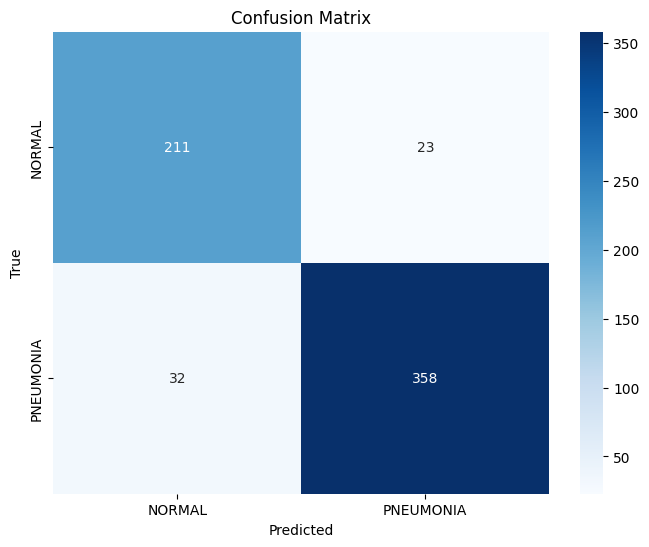


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.90      0.88       234
   PNEUMONIA       0.94      0.92      0.93       390

    accuracy                           0.91       624
   macro avg       0.90      0.91      0.91       624
weighted avg       0.91      0.91      0.91       624

True Negatives  — NORMAL correctly identified:     211
False Positives — NORMAL wrongly called PNEUMONIA: 23
False Negatives — PNEUMONIA missed:                32
True Positives  — PNEUMONIA correctly identified:  358


In [11]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs > FINAL_THRESHOLD).astype(int).flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred, target_names=CLASS_NAMES
))


tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  — NORMAL correctly identified:     {tn}")
print(f"False Positives — NORMAL wrongly called PNEUMONIA: {fp}")
print(f"False Negatives — PNEUMONIA missed:                {fn}")
print(f"True Positives  — PNEUMONIA correctly identified:  {tp}")

In [14]:
#Fixing False Positive Issue by trying differnt thresholds and find the best balance
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

# Initialize best_f1 and best_threshold
best_f1 = -1
best_threshold = 0.0

print(f"{'Threshold':<12} {'Accuracy': <12} {'Precision':<12}{'Recall':<12}{'F1': <10}{'FN':<8}{'FP':<8}")
print("-"*74)

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose = 0)
y_true = test_gen.classes



for thresh in thresholds:
  y_pred = (y_pred_probs > thresh).astype(int).flatten()

  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


  accuracy = (tp + tn) / (tp + tn + fp + fn)
  precision = tp/(tp+fp) if (tp + fp) > 0 else 0
  recall = tp/(tp + fn) if (tp + fn) > 0 else 0
  f1 = 2* (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


  print(f"{thresh:<12}{accuracy*100:<12.2f}{precision*100:12.2f}{recall*100:<12.2f}{f1*100:<10.2f}{fn:<8} {fp:<8}")


  if f1> best_f1:
    best_f1 = f1
    best_threshold = thresh

print(f"\nBest threshold: {best_threshold} with f1: {best_f1*100:.2f}%")

Threshold    Accuracy     Precision   Recall      F1        FN      FP      
--------------------------------------------------------------------------
0.3         91.67              92.2594.62       93.42     21       31      
0.35        91.35              92.6493.59       93.11     25       29      
0.4         91.51              93.3293.08       93.20     27       26      
0.45        91.19              93.7392.05       92.88     31       24      
0.5         91.19              93.9691.79       92.87     32       23      
0.55        90.71              94.1590.77       92.43     36       22      
0.6         90.22              94.3489.74       91.98     40       21      
0.65        89.74              94.7888.46       91.51     45       19      
0.7         89.90              95.5487.95       91.59     47       16      

Best threshold: 0.3 with f1: 93.42%


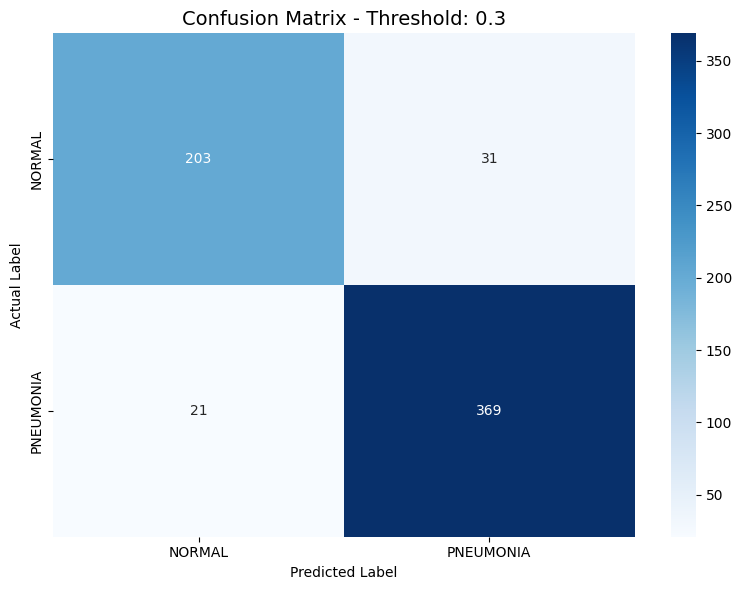


Final Classification Report (threshold=:0.3)
              precision    recall  f1-score   support

      NORMAL       0.91      0.87      0.89       234
   PNEUMONIA       0.92      0.95      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624

True Negatives  — NORMAL Case correctly identified:     203
False Positives — NORMAL Case wrongly called PNEUMONIA: 31
False Negatives — PNEUMONIA Case missed:                21
True Positives  — PNEUMONIA  Case correctly identified:  369


In [15]:
# Applying Best Threshold for the model

y_pred_best = (y_pred_probs > best_threshold).astype(int).flatten()
cm_best = confusion_matrix(y_true, y_pred_best)
plt.figure(figsize = (8,6))
sns.heatmap(
    cm_best,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES
)
plt.title(f'Confusion Matrix - Threshold: {best_threshold}', fontsize = 14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


print(f"\nFinal Classification Report (threshold=:{best_threshold})")
print(classification_report(
    y_true, y_pred_best, target_names = CLASS_NAMES
))


tn, fp, fn, tp = cm_best.ravel()
print(f"True Negatives  — NORMAL Case correctly identified:     {tn}")
print(f"False Positives — NORMAL Case wrongly called PNEUMONIA: {fp}")
print(f"False Negatives — PNEUMONIA Case missed:                {fn}")
print(f"True Positives  — PNEUMONIA  Case correctly identified:  {tp}")